In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [140]:
df = pd.read_csv('../data/proccessed/cleaned_divar_data_grouped.csv')

print(df.shape)
df.head()

df.describe()


(8416, 11)


,Area,Rooms,Floor,Exact_Price,Age,Price_per_meter
count,8416.000000,8416.000000,8416.000000,8.416000e+03,8416.000000,8.416000e+03
mean,99.990851,2.009743,3.459601,3.286372e+10,9.877852,2.865410e+08
std,51.713303,0.736874,3.360500,5.348817e+11,8.403183,5.742448e+09
min,28.000000,1.000000,-1.000000,5.000000e+08,0.000000,4.545455e+06
25%,64.000000,2.000000,2.000000,7.800000e+09,2.000000,1.239360e+08
50%,86.000000,2.000000,3.000000,1.650000e+10,8.000000,1.990608e+08
75%,120.000000,2.000000,4.000000,3.250000e+10,17.000000,2.914438e+08
max,550.000000,4.000000,30.000000,4.900000e+13,34.000000,5.268817e+11


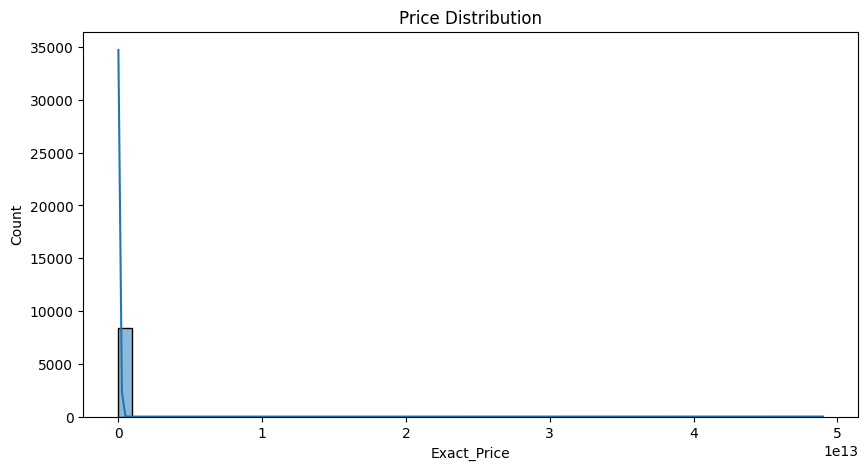

In [141]:
plt.figure(figsize=(10,5))
sns.histplot(df['Exact_Price'], bins=50, kde=True)

plt.title('Price Distribution')
plt.show()


In [142]:
df['Log_Price'] = np.log(df['Exact_Price'])


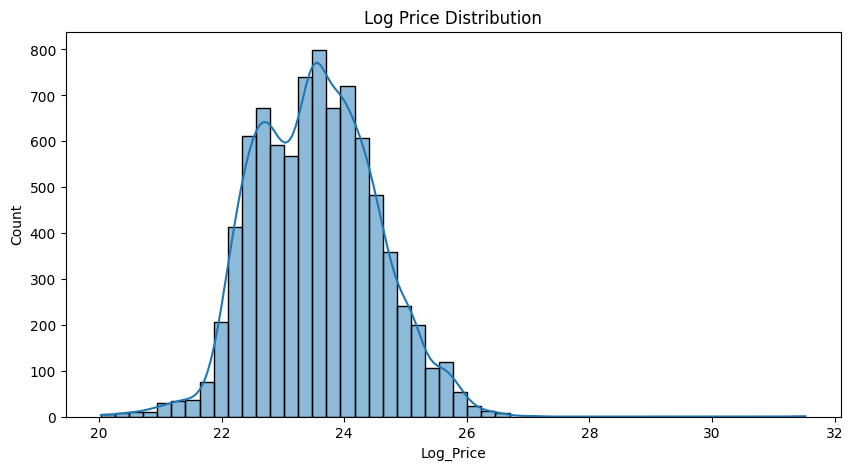

In [143]:
plt.figure(figsize=(10,5))
sns.histplot(df['Log_Price'], bins=50, kde=True)

plt.title('Log Price Distribution')
plt.show()


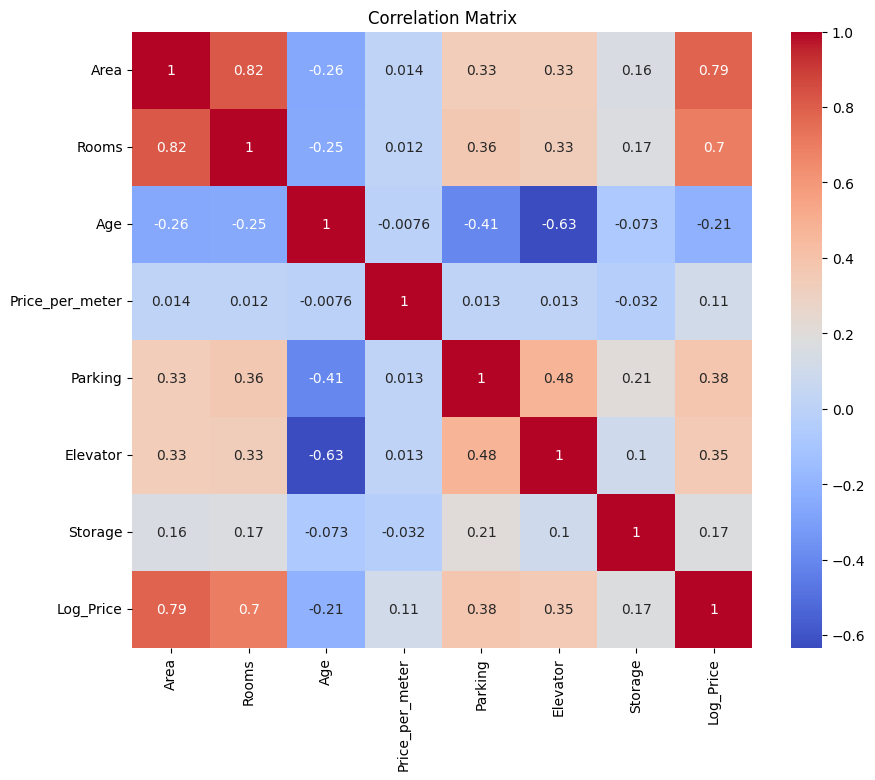

In [144]:
numeric_cols = [
    'Area',
    'Rooms',
    'Age',
    'Price_per_meter',
    'Parking',
    'Elevator',
    'Storage'
]

corr = df[numeric_cols + ['Log_Price']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()


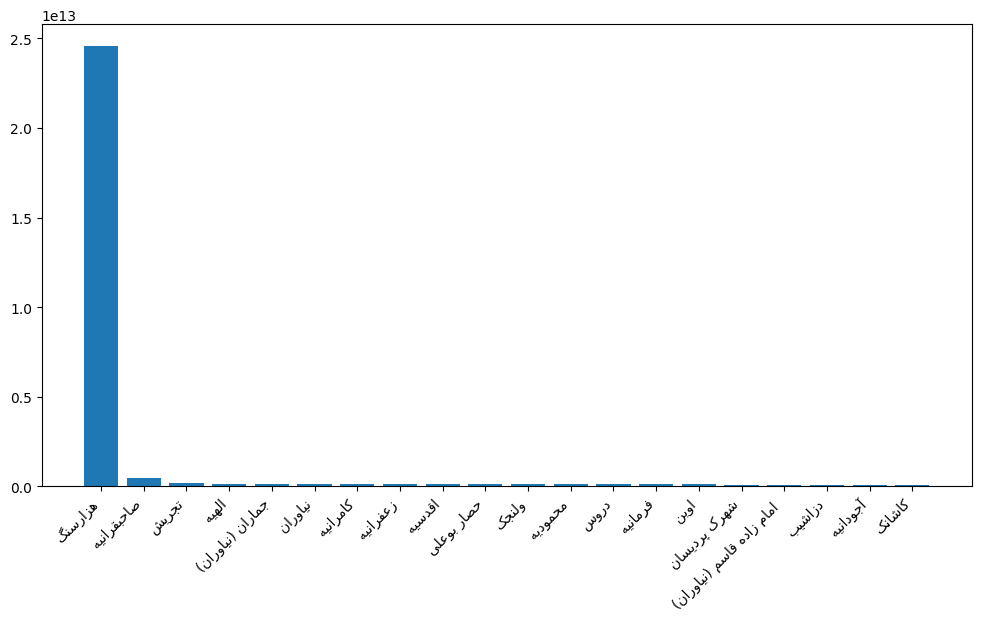

In [145]:
data_frame = pd.read_csv("../data/proccessed/cleaned_divar_data_grouped.csv")

import arabic_reshaper
from bidi.algorithm import get_display

def fix_farsi(text):
    return get_display(arabic_reshaper.reshape(text))

df_plot = data_frame.groupby("District")["Exact_Price"].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
plt.bar([fix_farsi(t) for t in df_plot.index], df_plot.values)
plt.xticks(rotation=45, ha='right')
plt.show()



In [146]:
df['Total_Amenities'] = (
    df['Parking'].astype(int) +
    df['Elevator'].astype(int) +
    df['Storage'].astype(int)
)
df['Area_Category'] = pd.cut(
    df['Area'],
    bins=[0, 80, 120, 200, 1000],
    labels=['Small', 'Medium', 'Large', 'Luxury']
)

df = pd.get_dummies(
    df,
    columns=['District', 'Area_Category'],
    drop_first=True
)


df.head()

,Token,Area,Rooms,Floor,Parking,Storage,Elevator,Exact_Price,Age,Price_per_meter,...,District_گمرک,District_گیشا,District_یاخجی آباد,District_یافت آباد جنوبی,District_یافت آباد شمالی,District_یافت‌آباد,District_یوسف‌آباد,Area_Category_Medium,Area_Category_Large,Area_Category_Luxury
0,Qa7zwo8C,275.0,4.0,5.0,True,True,True,165000003584,1.0,6.000000e+08,...,False,False,False,False,False,False,False,False,False,True
1,Qaf3zpPn,160.0,3.0,5.0,True,True,True,41999998976,8.0,2.625000e+08,...,False,False,False,False,False,False,False,False,True,False
2,gaDAz2ni,30.0,1.0,2.0,False,False,False,12999999488,25.0,4.333333e+08,...,False,False,False,False,False,False,False,False,False,False
3,QaxzNXTS,130.0,2.0,1.0,True,True,True,51000000512,16.0,3.923077e+08,...,False,False,False,False,False,False,False,False,True,False
4,Qa_Hxw6q,255.0,4.0,4.0,True,True,True,83999997952,11.0,3.294118e+08,...,False,False,False,False,False,False,False,False,False,True


In [147]:
df.to_csv("data",index=False, encoding='utf-8-sig')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8416 entries, 0 to 8415
Columns: 366 entries, Token to Area_Category_Luxury
dtypes: bool(357), float64(6), int64(2), object(1)
memory usage: 3.4+ MB


In [148]:
X = df.drop(['Exact_Price', 'Log_Price',"Token", "Price_per_meter"], axis=1)

y = df['Log_Price']


In [149]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


num_cols = ['Area', 'Age', 'Rooms', 'Floor'] 

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])



In [150]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)


LinearRegression()

In [151]:
y_pred = model.predict(X_test_scaled)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_test_real = np.exp(y_test) 
y_pred_real = np.exp(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)

mse = mean_squared_error(y_test_real, y_pred_real)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 4574825482.836392
RMSE: 11359010556.32895
R2 Score: 0.883870178163964


In [152]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


models = {
    "RandomForest": RandomForestRegressor(n_estimators=1000,min_samples_split=7,min_samples_leaf=1,max_features='log2',max_depth=None, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators= 2700, learning_rate=0.116887979427888, random_state=42, n_jobs=-1, subsample=0.9243044950338121 , min_child_weight=1, colsample_bytree=0.6347673172664886 , max_depth=4)
}

{'n_estimators': 2700, 'learning_rate': 0.116887979427888, 'max_depth': 4, 'subsample': 0.9243044950338121, 'colsample_bytree': 0.6347673172664886, 'min_child_weight': 1}



for name, model in models.items():
    print(f"--- Training {name} ---")
    
    model.fit(X_train_scaled, y_train) 
    
    y_pred_log = model.predict(X_test_scaled)
    
    y_test_real = np.exp(y_test) 
    y_pred_real = np.exp(y_pred_log)
    

    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test, y_pred_log)
    
    print(f"MAE (Real Price): {mae_real:,.0f}")
    print(f"RMSE (Real Price): {rmse_real:,.0f}")
    print(f"R2 Score: {r2:.5f}\n")



--- Training RandomForest ---
MAE (Real Price): 4,369,535,038
RMSE (Real Price): 8,731,178,133
R2 Score: 0.90333

--- Training XGBoost ---
MAE (Real Price): 3,654,938,023
RMSE (Real Price): 7,296,252,105
R2 Score: 0.92184



                             Feature  Importance
0                               Area    0.203864
1                              Rooms    0.124532
360              Area_Category_Large    0.071360
361             Area_Category_Luxury    0.064438
2                              Floor    0.049619
7                    Total_Amenities    0.041456
6                                Age    0.031843
359             Area_Category_Medium    0.031361
221              District_شهرک چیتگر    0.030847
3                            Parking    0.028828
5                           Elevator    0.027548
181                District_شهر زیبا    0.023303
132                    District_دروس    0.017430
136  District_دریاچه شهدای خلیج فارس    0.014766
102      District_جوانمردان (اندیشه)    0.010720


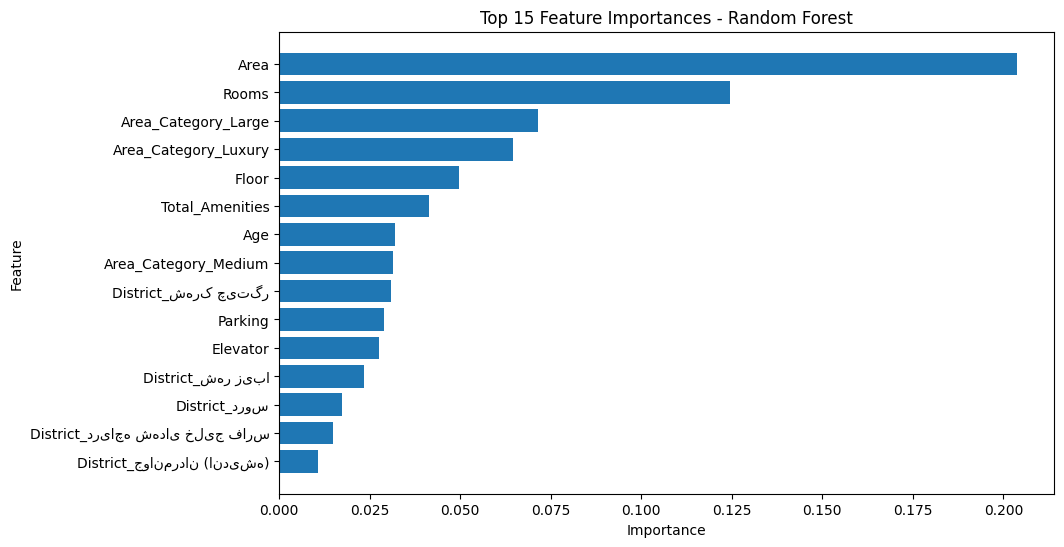

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
rf_model = models["RandomForest"]
importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)
print(feature_imp_df)
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()


In [154]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb


param_distributions = {
    'n_estimators': [500, 1000, 2000, 3000],          
    'learning_rate': [0.01, 0.05, 0.1, 0.2],     
    'max_depth': [3, 5, 7, 9],                   
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],          
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'min_child_weight': [1, 3, 5, 7]         
}
xgb_model = xgb.XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=120,              
    scoring='neg_mean_absolute_error',
    cv=3,                    
    verbose=2,              
    random_state=42,
    n_jobs=-1                
)
print("Starting Randomized Search... This might take a while!")
random_search.fit(X_train, y_train)

print("Best Parameters Found:")
print(random_search.best_params_)
best_xgb_model = random_search.best_estimator_


Starting Randomized Search... This might take a while!
Fitting 3 folds for each of 120 candidates, totalling 360 fits
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=500, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=500, subsample=0.8; total time=   1.8s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=500, subsample=0.8; total time=   1.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=500, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=500, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=7, n_estimators=500, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=3, min

In [155]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_param_grid = {
    'n_estimators': [100, 300, 500, 800, 1000],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 1.0]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=rf_param_grid, 
    n_iter=50, 
    scoring='r2', 
    cv=3, 
    verbose=2, 
    random_state=42,
    n_jobs=-1
)

print("Starting Randomized Search for Random Forest...")
rf_random_search.fit(X_train_scaled, y_train)

print("Best Parameters Found for Random Forest:")
print(rf_random_search.best_params_)


Starting Randomized Search for Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=1000; total time=   4.9s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=1000; total time=   5.3s
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=1000; total time=   6.7s
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.3s
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.0s
[CV] END max_depth=40, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=800; total time=  15.7s
[CV] END max_depth=40, max_features=0.3, min

In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 4000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3),
        'max_depth': trial.suggest_int('max_depth', 2, 7),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBRegressor(**param)
    
   
    scores = cross_val_score(
        model, X_train, y_train, 
        scoring='neg_mean_absolute_error', 
        cv=3,
        n_jobs=-1
    )
    
    mae = -scores.mean()
    return mae

print("Starting Optuna Study...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) 

print("\nBest Parameters from Optuna:")
print(study.best_params)


print("\nTraining final model with best parameters...")
best_xgb_model_optuna = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_xgb_model_optuna.fit(X_train, y_train)

y_pred_xgb = best_xgb_model_optuna.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- Final Model Evaluation on Test Data ---")
print(f"MAE: {mae_xgb:,.0f}")
print(f"RMSE: {rmse_xgb:,.0f}")
print(f"R2 Score: {r2_xgb:.5f}")


[I 2026-05-14 18:51:43,913] A new study created in memory with name: no-name-c2c4d84b-0b74-4d3d-aaae-09bbf2a3b884


Starting Optuna Study...


[I 2026-05-14 18:51:50,967] Trial 0 finished with value: 0.18257201434693862 and parameters: {'n_estimators': 2400, 'learning_rate': 0.17573050192493406, 'max_depth': 4, 'subsample': 0.8893147038224143, 'colsample_bytree': 0.5938583941917649, 'min_child_weight': 2}. Best is trial 0 with value: 0.18257201434693862.
[I 2026-05-14 18:52:00,999] Trial 1 finished with value: 0.18242145222733228 and parameters: {'n_estimators': 3600, 'learning_rate': 0.10399568998515414, 'max_depth': 4, 'subsample': 0.9472249390601921, 'colsample_bytree': 0.9061596565533521, 'min_child_weight': 2}. Best is trial 1 with value: 0.18242145222733228.
[I 2026-05-14 18:52:10,611] Trial 2 finished with value: 0.19562017355665218 and parameters: {'n_estimators': 3600, 'learning_rate': 0.12143186836504473, 'max_depth': 2, 'subsample': 0.6670048267601252, 'colsample_bytree': 0.7980544365287005, 'min_child_weight': 5}. Best is trial 1 with value: 0.18242145222733228.
[I 2026-05-14 18:52:15,201] Trial 3 finished with va


Best Parameters from Optuna:
{'n_estimators': 3200, 'learning_rate': 0.19270425014957054, 'max_depth': 3, 'subsample': 0.904061180683979, 'colsample_bytree': 0.908284801001642, 'min_child_weight': 1}

Training final model with best parameters...

--- Final Model Evaluation on Test Data ---
MAE: 0
RMSE: 0
R2 Score: 0.91677


In [157]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = RandomForestRegressor(**param, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

study_rf = optuna.create_study(direction='minimize')
print("Starting Optuna optimization for Random Forest...")
study_rf.optimize(objective_rf, n_trials=50)

print("\nBest Trial:")
print("  Value (Log MAE):", study_rf.best_trial.value)
print("  Params: ")
for key, value in study_rf.best_trial.params.items():
    print(f"    {key}: {value}")
print("\nTraining final Random Forest model with best parameters...")
best_rf_model = RandomForestRegressor(**study_rf.best_trial.params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train, y_train)
y_pred_log_rf = best_rf_model.predict(X_test)

y_pred_real_rf = np.expm1(y_pred_log_rf)
y_test_real = np.expm1(y_test)

mae_rf = mean_absolute_error(y_test_real, y_pred_real_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, y_pred_real_rf))
r2_rf = r2_score(y_test_real, y_pred_real_rf)

print("\n--- Final RandomForest Model Evaluation on Test Data ---")
print(f"MAE (Real Price): {mae_rf:,.0f}")
print(f"RMSE (Real Price): {rmse_rf:,.0f}")
print(f"R2 Score: {r2_rf:.5f}")


[I 2026-05-14 18:58:21,638] A new study created in memory with name: no-name-090af835-d974-4cd3-8291-1ed1861a7b37


Starting Optuna optimization for Random Forest...


[I 2026-05-14 18:58:23,147] Trial 0 finished with value: 0.4219210515494611 and parameters: {'n_estimators': 500, 'max_depth': 39, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.4219210515494611.
[I 2026-05-14 18:58:26,142] Trial 1 finished with value: 0.3729156202881888 and parameters: {'n_estimators': 800, 'max_depth': 32, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.3729156202881888.
[I 2026-05-14 18:58:28,178] Trial 2 finished with value: 0.4292186427559498 and parameters: {'n_estimators': 700, 'max_depth': 26, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.3729156202881888.
[I 2026-05-14 18:58:31,597] Trial 3 finished with value: 0.27611131999692085 and parameters: {'n_estimators': 100, 'max_depth': 49, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 3 with value: 0.2761113199969


Best Trial:
  Value (Log MAE): 0.22841985890363792
  Params: 
    n_estimators: 500
    max_depth: 48
    min_samples_split: 5
    min_samples_leaf: 1
    max_features: sqrt

Training final Random Forest model with best parameters...

--- Final RandomForest Model Evaluation on Test Data ---
MAE (Real Price): 4,833,900,905
RMSE (Real Price): 9,068,050,048
R2 Score: 0.90357


In [158]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def objective_rf(trial):

    param = {

        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        

        'max_depth': trial.suggest_categorical('max_depth', [None, 10, 20, 30, 40, 50]),
        

        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        

        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        

        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }


    model = RandomForestRegressor(
        **param, 
        random_state=42, 
        n_jobs=-1 
    )


    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    return -scores.mean()


study_rf = optuna.create_study(direction='minimize')
print("Starting Optuna optimization for Random Forest...")

study_rf.optimize(objective_rf, n_trials=50)

print("\nBest Trial:")
print("  Value (Log MAE):", study_rf.best_trial.value)
print("  Params: ")
for key, value in study_rf.best_trial.params.items():
    print(f"    {key}: {value}")
print("\nTraining final Random Forest model with best parameters...")
best_rf_model = RandomForestRegressor(
    **study_rf.best_trial.params, 
    random_state=42, 
    n_jobs=-1
)
best_rf_model.fit(X_train, y_train)
y_pred_log_rf = best_rf_model.predict(X_test)
y_pred_real_rf = np.expm1(y_pred_log_rf)
y_test_real = np.expm1(y_test)
mae_rf = mean_absolute_error(y_test_real, y_pred_real_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, y_pred_real_rf))
r2_rf = r2_score(y_test_real, y_pred_real_rf)

print("\n--- Final RandomForest Model Evaluation on Test Data ---")
print(f"MAE (Real Price): {mae_rf:,.0f}")
print(f"RMSE (Real Price): {rmse_rf:,.0f}")
print(f"R2 Score: {r2_rf:.5f}")


[I 2026-05-14 19:08:56,332] A new study created in memory with name: no-name-edf0dde3-3665-4414-8916-fe063780ce39


Starting Optuna optimization for Random Forest...


[I 2026-05-14 19:08:57,212] Trial 0 finished with value: 0.35070808346995525 and parameters: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.35070808346995525.
[I 2026-05-14 19:09:00,144] Trial 1 finished with value: 0.39643377140258307 and parameters: {'n_estimators': 1000, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.35070808346995525.
[I 2026-05-14 19:09:03,670] Trial 2 finished with value: 0.33169893494660085 and parameters: {'n_estimators': 900, 'max_depth': 50, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.33169893494660085.
[I 2026-05-14 19:09:07,721] Trial 3 finished with value: 0.26054585618329595 and parameters: {'n_estimators': 600, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.260


Best Trial:
  Value (Log MAE): 0.20205245493989712
  Params: 
    n_estimators: 500
    max_depth: None
    min_samples_split: 3
    min_samples_leaf: 1
    max_features: log2

Training final Random Forest model with best parameters...

--- Final RandomForest Model Evaluation on Test Data ---
MAE (Real Price): 4,210,989,847
RMSE (Real Price): 8,390,385,391
R2 Score: 0.91744
